# Bài tập thực hành tuần 5

> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import heapq
import sys
from time import perf_counter
from math import log2

### Bài tập 1:
**Câu hỏi**:

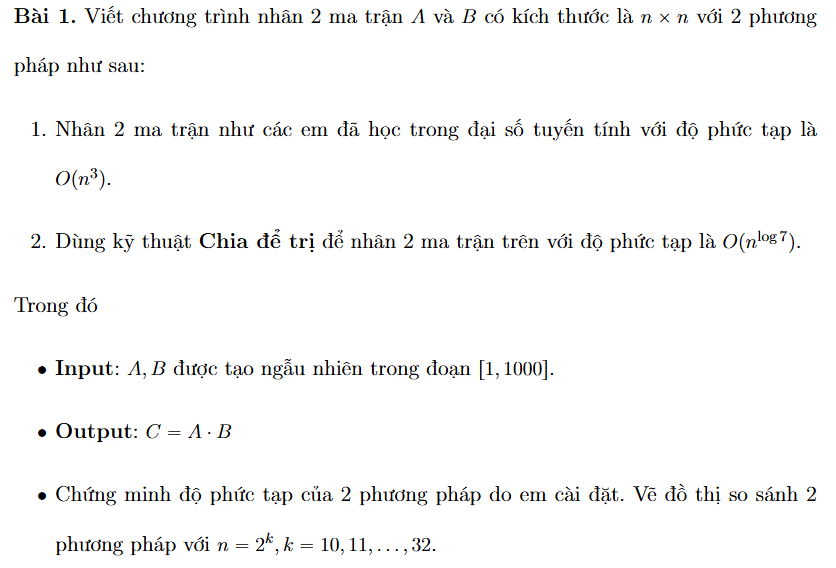

k = 1, n = 2
Basic multi: 0.0001 s
Strassen multi: 0.0001 s
k = 2, n = 4
Basic multi: 0.0000 s
Strassen multi: 0.0003 s
k = 3, n = 8
Basic multi: 0.0003 s
Strassen multi: 0.0015 s
k = 4, n = 16
Basic multi: 0.0020 s
Strassen multi: 0.0096 s
k = 5, n = 32
Basic multi: 0.0109 s
Strassen multi: 0.0502 s
k = 6, n = 64
Basic multi: 0.0791 s
Strassen multi: 0.3794 s
k = 7, n = 128
Basic multi: 0.6797 s
Strassen multi: 2.7362 s
k = 8, n = 256
Basic multi: 6.3574 s
Strassen multi: 21.2904 s
k = 9, n = 512
Basic multi: 43.1096 s
Strassen multi: 137.4592 s


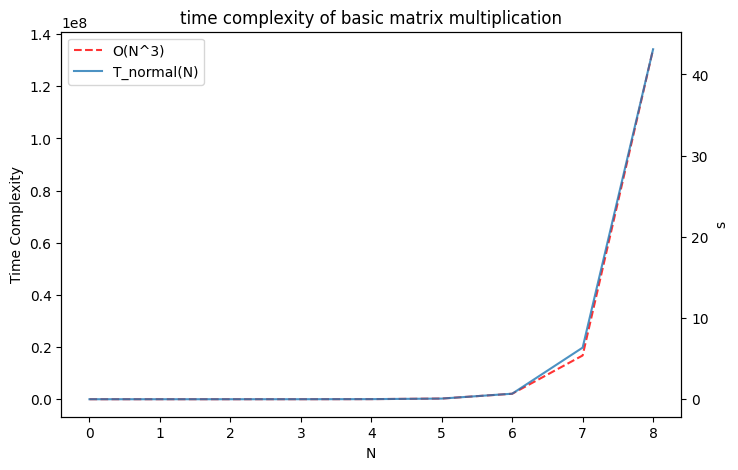

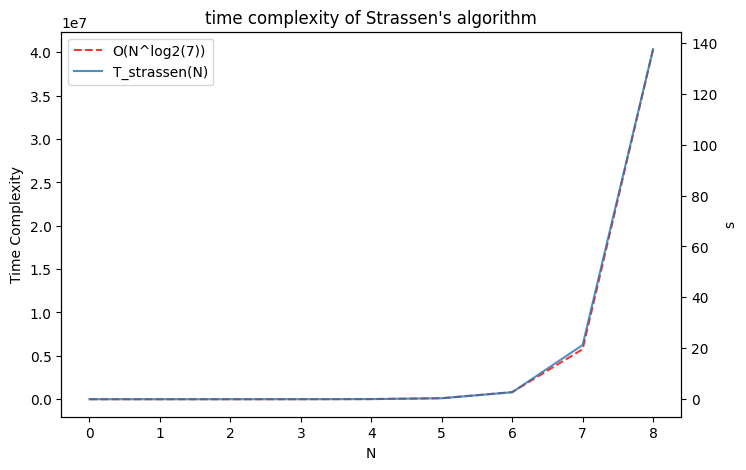

Text(0.5, 1.0, 'comparison of basic multi and Strassen multi')

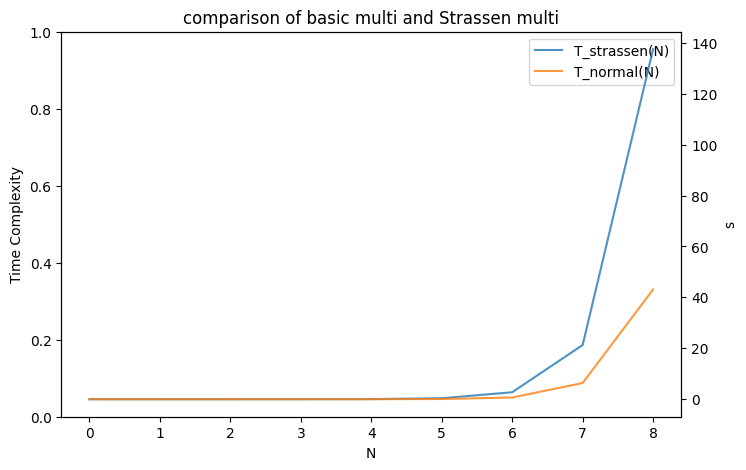

In [ ]:
def generate_matrix(n):
    return np.random.randint(1, 1001, size=(n, n))

# 1
def multiply(A, B):
    row_A, col_A = len(A), len(A[0])
    row_B, col_B = len(B), len(B[0])

    if col_A != row_B:
        raise ValueError('invalid dimensions')

    C = [[0 for _ in range(col_B)] 
         for _ in range(row_A)]

    for i in range(row_A):
        for j in range(col_B):
            for k in range(row_B):
                C[i][j] += A[i][k] * B[k][j]
    return C


# 2

def split(matrix):
    n = len(matrix)
    return matrix[:n//2, :n//2], matrix[:n//2, n//2:], matrix[n//2:, :n//2], matrix[n//2:, n//2:]

def strassen(A, B):
    if len(A) == 1:
        return A * B

    a11, a12, a21, a22 = split(A)
    b11, b12, b21, b22 = split(B)

    p1 = strassen(a11 + a22, b11 + b22)
    p2 = strassen(a21 + a22, b11)
    p3 = strassen(a11, b12 - b22)
    p4 = strassen(a22, b21 - b11)
    p5 = strassen(a11 + a12, b22)
    p6 = strassen(a21 - a11, b11 + b12)
    p7 = strassen(a12 - a22, b21 + b22)

    c11 = p1 + p4 - p5 + p7
    c12 = p3 + p5
    c21 = p2 + p4
    c22 = p1 + p3 - p2 + p6
    return np.vstack((np.hstack((c11, c12)), np.hstack((c21, c22))))

T_normal, T_strassen = [], []
Ns = []
# wtf why the frick k = 10-32 is too much for a potato laptop :skull:
for k in range(1, 10):
    n = 2 ** k
    Ns.append(n)
    print(f'{k = }, {n = }')
    A = generate_matrix(n)
    B = generate_matrix(n)
    
    
    tic = perf_counter()
    C = multiply(A, B)
    T_normal.append(perf_counter() - tic)
    print('Basic multi:' + f' {T_normal[-1]:.4f} s')
    
    tic = perf_counter()
    C = strassen(A, B)
    T_strassen.append(perf_counter() - tic)
    print('Strassen multi:' + f' {T_strassen[-1]:.4f} s')


bigO_line = list(map(lambda x: x**3, Ns))
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax2 = ax.twinx()
ax.set_xlabel('N')
line1, = ax.plot(bigO_line, label=r'O(N^3)', color='r', ls='--', alpha=0.8)
ax.set_ylabel('Time Complexity')
line2, = ax2.plot(T_normal, label=r'T_normal(N)', color='C0', alpha=0.8)
ax2.set_ylabel('s')
ax.legend(handles=[line1, line2])
plt.title('time complexity of basic matrix multiplication')
plt.show()

bigO_line = list(map(lambda x: x**np.log2(7), Ns))
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax2 = ax.twinx()
ax.set_xlabel('N')
line1, = ax.plot(bigO_line, label=r'O(N^log2(7))', color='r', ls='--', alpha=0.8)
ax.set_ylabel('Time Complexity')
line2, = ax2.plot(T_strassen, label=r'T_strassen(N)', color='C0', alpha=0.8)
ax2.set_ylabel('s')
ax.legend(handles=[line1, line2])
plt.title('time complexity of Strassen\'s algorithm')
plt.show()
# combine 2 plots
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax2 = ax.twinx()
ax.set_xlabel('N')
ax.set_ylabel('Time Complexity')
line1, = ax2.plot(T_strassen, label=r'T_strassen(N)', color='C0', alpha=0.8)
line2, = ax2.plot(T_normal, label=r'T_normal(N)', color='C1', alpha=0.8)
ax2.set_ylabel('s')
ax.legend(handles=[line1, line2])
plt.title('comparison of basic multi and Strassen multi')

Hàm `generate_matrix(n)` tạo ra một ma trận vuông n x n với các phần tử trong đoạn [1, 1000] được chọn ngẫu nhiên.
```python
def generate_matrix(n):
    return np.random.randint(1, 1001, size=(n, n))
```

Hàm `multiply(A, B)` thực hiện phép nhân ma trận cơ bản giữa hai ma trận A và B. hoạt động theo các bước sau:
1. Xác định số dòng và số cột của ma trận A và B.
2. Kiểm tra nếu số cột của A không bằng số dòng của B, thì ném ra lỗi về kích thước không hợp lệ.
3. Tạo một ma trận kết quả C có kích thước bằng số dòng của A và số cột của B, được khởi tạo với tất cả phần tử bằng 0.
4. Sử dụng ba vòng lặp lồng nhau để tính toán giá trị của mỗi phần tử trong ma trận C bằng cách nhân và cộng các phần tử tương ứng từ A và B.
5. Trả về ma trận kết quả C.
```py
def multiply(A, B):
    row_A, col_A = len(A), len(A[0])
    row_B, col_B = len(B), len(B[0])

    if col_A != row_B:
        raise ValueError('invalid dimensions')

    C = [[0 for _ in range(col_B)] 
         for _ in range(row_A)]

    for i in range(row_A):
        for j in range(col_B):
            for k in range(row_B):
                C[i][j] += A[i][k] * B[k][j]
    return C
```


Hàm `split(matrix)` chia một ma trận vuông thành bốn phần tư bằng cách cắt nó thành hai nửa theo chiều dọc và hai nửa theo chiều ngang. Hàm trả về bốn ma trận con tương ứng với bốn phần tư của ma trận ban đầu.
```python
def split(matrix):
    n = len(matrix)
    return matrix[:n//2, :n//2], matrix[:n//2, n//2:], matrix[n//2:, :n//2], matrix[n//2:, n//2:]
```

Hàm `strassen(A, B)` thực hiện thuật toán Strassen để nhân hai ma trận A và B. Thuật toán này hoạt động theo các bước sau:
1. Nếu ma trận A có kích thước 1x1, trả về tích của A và B.
2. Chia ma trận A và B thành bốn phần tư bằng cách sử dụng hàm `split()`.
3. Tính bảy ma trận tạm thời p1 đến p7 bằng cách sử dụng đệ quy để gọi hàm `strassen()` trên các phần tư của A và B theo công thức của thuật toán Strassen.
4. Tính các phần tư của ma trận kết quả C bằng cách kết hợp các ma trận tạm thời p1 đến p7 theo công thức của thuật toán Strassen.
5. Kết hợp bốn phần tư của ma trận C thành một ma trận kết quả duy nhất và trả về nó.
```python
def strassen(A, B):
    if len(A) == 1:
        return A * B
    a11, a12, a21, a22 = split(A)
    b11, b12, b21, b22 = split(B)
    p1 = strassen(a11 + a22, b11 + b22)
    p2 = strassen(a21 + a22, b11)
    p3 = strassen(a11, b12 - b22)
    p4 = strassen(a22, b21 - b11)
    p5 = strassen(a11 + a12, b22)
    p6 = strassen(a21 - a11, b11 + b12)
    p7 = strassen(a12 - a22, b21 + b22)
    c11 = p1 + p4 - p5 + p7
    c12 = p3 + p5
    c21 = p2 + p4
    c22 = p1 + p3 - p2 + p6
    return np.vstack((np.hstack((c11, c12)), np.hstack((c21, c22))))
``` 

Cuối cùng, chương trình chính thực hiện các bước sau:
1. Tạo hai danh sách rỗng `T_normal` và `T_strassen` để lưu trữ thời gian thực thi của thuật toán nhân ma trận cơ bản và thuật toán Strassen tương ứng.
2. Tạo một danh sách `Ns` để lưu trữ các kích thước của ma trận được sử dụng trong các phép nhân.
3. Sử dụng một vòng lặp để lặp qua các giá trị của k từ 1 đến 9 (vì máy laptop yếu) để tạo ra các ma trận có kích thước 2^k x 2^k.
4. Trong mỗi vòng lặp, tạo hai ma trận A và B bằng cách gọi hàm `generate_matrix(n)`.
5. Đo thời gian thực thi của hàm `multiply(A, B)` và lưu trữ thời gian này vào danh sách `T_normal`.
6. Đo thời gian thực thi của hàm `strassen(A, B)` và lưu trữ thời gian này vào danh sách `T_strassen`.
7. Vẽ biểu đồ so sánh thời gian thực thi của hai thuật toán nhân ma trận cơ bản và Strassen với đường O(N^3) và O(N^log2(7)) tương ứng để minh họa độ phức tạp thời gian của chúng.
```python
T_normal, T_strassen = [], []
Ns = []
for k in range(1, 10):
    n = 2 ** k
    Ns.append(n)
    print(f'{k = }, {n = }')
    A = generate_matrix(n)
    B = generate_matrix(n)
    tic = perf_counter()
    C = multiply(A, B)
    T_normal.append(perf_counter() - tic)
    print('Basic multi:' + f' {T_normal[-1]:.4f} s')
    tic = perf_counter()
    C = strassen(A, B)
    T_strassen.append(perf_counter() - tic)
    print('Strassen multi:' + f' {T_strassen[-1]:.4f} s')
``` 

Kết quả từ đồ thị cho thấy thuật toán nhân ma trận cơ bản có độ phức tạp thời gian rất giống với O(N^3), trong khi thuật toán Strassen có độ phức tạp thời gian tốt hơn và rất giống với O(N^log2(7)). 

Khi so sánh 2 thuật toán, chúng ta thấy rằng Strassen nhanh hơn đáng kể so với thuật toán nhân ma trận cơ bản, đặc biệt là khi kích thước của ma trận tăng lên. Điều này chứng tỏ rằng thuật toán Strassen có độ phức tạp thời gian tốt hơn so với thuật toán nhân ma trận cơ bản.



### Bài tập 2:
**Câu hỏi**:

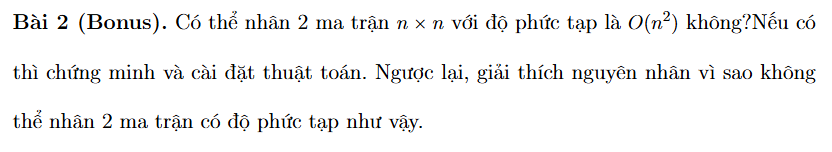

Không tồn tại thuật toán nào có thể nhân 2 ma trận n x n với độ phức tạp thời gian là O($n^2$) hiện tại.

Đơn giản vì khi nhân 2 ma trận n x n, chúng ta đã thực hiện việc đọc n dòng và n cột của mỗi ma trận là đã có độ phức tạp O($n^2$). Hơn nữa nếu ta gán vào ma trận kết quả thì cũng đã phải thực hiện n x n phép gán, điều này cũng đã có độ phức tạp O($n^2$) nên việc mà tồn tại một thuật toán nào đó có độ phức tạp thời gian tốt hơn O($n^2$) để nhân 2 ma trận n x n không khả thi.

Đồng thời nếu xét theo lý thuyết thì độ phức tạp thời gian tối thiểu tuyệt đối để nhân 2 ma trận n x n là $\Omega(n^2)$, điều này có nghĩa là không thể có thuật toán nào có độ phức tạp thời gian tốt hơn O($n^2$) để nhân 2 ma trận n x n.

Và thuật toán nhân 2 ma trận n x n có độ phức tạp tốt nhất hiện nay chỉ là O($n^{2.3728596}$) do Alman và Williams vào năm 2020.